In [10]:
# --- Core Python ---
import os
import sys
from pathlib import Path
import h5py
import re

# Ensure notebook-local helper modules are importable
_NB_DIR = Path.cwd()
print(f"currently in {_NB_DIR}")
if (_NB_DIR / "resp_helper_functions.py").exists():
    print("helper functions exists in working directory, adding to sys.path")
    sys.path.insert(0, str(_NB_DIR))
else:
    # Fallback when notebook is launched from workspace root
    _NB_DIR = Path("notebooks/thomas_notebooks/resp_classification").resolve()
    if (_NB_DIR / "resp_helper_functions.py").exists():
        sys.path.insert(0, str(_NB_DIR))
    print("Helper functions didn't exist in working directory, resolving and adding to sys.path")

# --- Numerical & data analysis ---
import numpy as np
import pandas as pd

# --- Plotting ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Signal processing ---
from scipy.signal import butter, filtfilt, resample_poly, find_peaks

# --- Statistics ---
from scipy.stats import wilcoxon

# --- Machine learning & metrics ---
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# --- Specialized neurophysiology tools ---
import neurokit2 as nk

# All the functions used to load, clean, and verify respiration and BORIS data
from resp_helper_functions import *

# --- Pandas display settings ---
pd.set_option("display.max_rows", 50)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 1000)

currently in c:\Users\thoma\Code\ResearchCode\respiratory_pilot
Helper functions didn't exist in working directory, resolving and adding to sys.path


In [11]:
np.floor(5*0.1)

np.float64(0.0)

In [12]:
feature_matrix = pd.read_pickle(r"C:\Users\thoma\Code\ResearchCode\respiratory_pilot\notebooks\thomas_notebooks\resp_classification\data\raw-breathmetrics-features-session")
feature_matrix.columns

Index(['WindowID', 'Start', 'Stop', 'Duration', 'n_breaths', 'breathing_rate_hz', 'mean_ibi_sec', 'cv_breathing_rate', 'mean_inhale_dur_sec', 'cv_inhale_dur', 'mean_exhale_dur_sec', 'cv_exhale_dur', 'ie_ratio', 'mean_peak_insp_flow', 'mean_peak_exp_flow', 'cv_peak_insp_flow', 'mean_inhale_vol', 'mean_exhale_vol', 'mean_tidal_vol', 'cv_tidal_vol', 'minute_ventilation', 'pct_breaths_with_inhale_pause', 'mean_inhale_pause_dur_sec', 'cv_inhale_pause_dur', 'inhale_pause_duty_cycle', 'pct_breaths_with_exhale_pause', 'mean_exhale_pause_dur_sec', 'cv_exhale_pause_dur', 'exhale_pause_duty_cycle', 'inhale_duty_cycle', 'exhale_duty_cycle', 'Trial', 'Subject', 'Condition', 'Rank', 'Type', 'session_duration_sec', 'n_breaths_total', 'WindowSec', 'n_bouts_anogenital_sniffing', 'n_bouts_body_sniffing', 'n_bouts_facial_sniffing', 'total_dur_anogenital_sniffing', 'total_dur_body_sniffing', 'total_dur_facial_sniffing'], dtype='object')

In [13]:
print(feature_matrix["Condition"].value_counts())

Condition
RI1     792
BLRI    694
RI2     690
Name: count, dtype: int64


In [14]:
feature_matrix

,WindowID,Start,Stop,Duration,n_breaths,breathing_rate_hz,mean_ibi_sec,cv_breathing_rate,mean_inhale_dur_sec,cv_inhale_dur,mean_exhale_dur_sec,cv_exhale_dur,ie_ratio,mean_peak_insp_flow,mean_peak_exp_flow,cv_peak_insp_flow,mean_inhale_vol,mean_exhale_vol,mean_tidal_vol,cv_tidal_vol,minute_ventilation,pct_breaths_with_inhale_pause,mean_inhale_pause_dur_sec,cv_inhale_pause_dur,inhale_pause_duty_cycle,pct_breaths_with_exhale_pause,mean_exhale_pause_dur_sec,cv_exhale_pause_dur,exhale_pause_duty_cycle,inhale_duty_cycle,exhale_duty_cycle,Trial,Subject,Condition,Rank,Type,session_duration_sec,n_breaths_total,WindowSec,n_bouts_anogenital_sniffing,n_bouts_body_sniffing,n_bouts_facial_sniffing,total_dur_anogenital_sniffing,total_dur_body_sniffing,total_dur_facial_sniffing
0,0,5.0,10.0,5.0,28,5.501783,0.181759,0.591457,0.082768,0.897816,0.081429,0.399243,1.016447,1019.844129,-828.772393,0.314966,50797.016231,40274.510629,91071.526860,0.709522,501055.776916,0.000000,0.00000,NaN,0.000000,0.035714,0.31500,0.000000,0.061895,0.455371,0.448002,RI1_3_6,3_6,RI1,Dominant,Interaction,603.2700,3902,5.0,9.0,4.0,3.0,16.998,2.068,3.069
1,1,10.0,15.0,5.0,50,10.129199,0.098724,0.252408,0.045750,0.398907,0.048000,0.376156,0.953125,1372.540171,-1148.885687,0.325553,44836.657875,37908.416042,82745.073917,0.467869,838141.317192,0.000000,0.00000,NaN,0.000000,0.000000,0.00000,NaN,0.000000,0.463411,0.486202,RI1_3_6,3_6,RI1,Dominant,Interaction,603.2700,3902,5.0,9.0,4.0,3.0,16.998,2.068,3.069
2,2,15.0,20.0,5.0,44,8.875129,0.112674,0.399851,0.052614,0.616626,0.054773,0.490417,0.960581,1384.334752,-1052.148340,0.331608,48284.912045,39148.603503,87433.515548,0.499931,775983.729320,0.000000,0.00000,NaN,0.000000,0.000000,0.00000,NaN,0.000000,0.466953,0.486115,RI1_3_6,3_6,RI1,Dominant,Interaction,603.2700,3902,5.0,9.0,4.0,3.0,16.998,2.068,3.069
3,3,20.0,25.0,5.0,49,9.657948,0.103542,0.219408,0.045714,0.310147,0.052551,0.381369,0.869903,1310.878616,-1016.316795,0.308133,41970.476502,36753.275175,78723.751677,0.445387,760309.875351,0.000000,0.00000,NaN,0.000000,0.000000,0.00000,NaN,0.000000,0.441506,0.507535,RI1_3_6,3_6,RI1,Dominant,Interaction,603.2700,3902,5.0,9.0,4.0,3.0,16.998,2.068,3.069
4,4,25.0,30.0,5.0,47,9.416581,0.106196,0.235299,0.045053,0.382822,0.055904,0.309058,0.805899,1186.557865,-989.598314,0.294919,37206.497129,38124.129724,75330.626853,0.456828,709356.977531,0.000000,0.00000,NaN,0.000000,0.000000,0.00000,NaN,0.000000,0.424247,0.526427,RI1_3_6,3_6,RI1,Dominant,Interaction,603.2700,3902,5.0,9.0,4.0,3.0,16.998,2.068,3.069
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2171,95,575.0,580.0,5.0,23,4.609743,0.216932,0.494583,0.099891,0.833022,0.092174,0.433542,1.083726,1250.376838,-1140.391672,0.397200,56151.943399,58659.832935,114811.776334,0.436596,529252.819140,0.043478,0.07500,0.000000,0.015032,0.173913,0.07125,0.726112,0.057121,0.460473,0.424898,BLRI_4_8,4_8,BLRI,Dominant,Baseline,605.0125,4351,5.0,NaN,NaN,NaN,NaN,NaN,NaN
2172,96,580.0,585.0,5.0,32,6.408269,0.156048,0.625644,0.056406,0.424962,0.068437,0.362863,0.824201,1524.971228,-1198.531717,0.322266,57210.277761,54548.369624,111758.647385,0.460070,716179.445774,0.062500,0.05375,0.302326,0.021528,0.125000,0.18000,0.788554,0.144186,0.361466,0.438566,BLRI_4_8,4_8,BLRI,Dominant,Baseline,605.0125,4351,5.0,NaN,NaN,NaN,NaN,NaN,NaN
2173,97,585.0,590.0,5.0,44,8.802456,0.113605,0.197360,0.047273,0.155341,0.061250,0.327515,0.771800,1551.544168,-1230.303031,0.281923,50733.919767,49967.386995,100701.306762,0.363612,886418.872214,0.000000,0.00000,NaN,0.000000,0.000000,0.00000,NaN,0.000000,0.416116,0.539150,BLRI_4_8,4_8,BLRI,Dominant,Baseline,605.0125,4351,5.0,NaN,NaN,NaN,NaN,NaN,NaN
2174,98,595.0,600.0,5.0,39,7.704004,0.129803,0.449421,0.052564,0.415394,0.066218,0.500929,0.793804,1396.996279,-1025.896481,0.255086,47476.646944,46888.672423,94365.319368,0.320916,726990.803036,0.00

In [15]:
# Keep only target classes of interest
TARGET_COL = "Condition"
TARGET_CLASSES = ["RI1", "RI2", "BLRI"]

df = feature_matrix.copy()
df = df[df[TARGET_COL].isin(TARGET_CLASSES)].reset_index(drop=True)

# Explicit metadata + non-feature columns to exclude
EXCLUDE_FROM_FEATURES = {
    TARGET_COL,
    "Behavior",
    "Start",
    "Stop",
    "Duration",
    "Trial",
    "Subject",
    "Rank",
    "Type",
    "Label",
}

# Add any pre-defined metadata columns if present
if "METADATA_COLS" in globals() and isinstance(METADATA_COLS, (list, tuple, set)):
    EXCLUDE_FROM_FEATURES.update(METADATA_COLS)

# Keep only numeric respiratory features
candidate_feature_cols = [
    c for c in df.columns
    if c not in EXCLUDE_FROM_FEATURES and pd.api.types.is_numeric_dtype(df[c])
]

X_all = df[candidate_feature_cols].copy()
y = df[TARGET_COL].copy()

# Optional grouping variable for group-aware CV to prevent leakage across recordings
# Prefer Trial (if recording-level), otherwise fallback to Subject, else None.
groups = None
if "Trial" in df.columns:
    groups = df["Trial"].copy()
elif "Subject" in df.columns:
    groups = df["Subject"].copy()

In [16]:
# Build CV strategy: grouped splits when possible, otherwise stratified shuffled folds
if groups is not None and groups.nunique() >= 3:
    n_splits = min(5, groups.nunique())
    cv = GroupKFold(n_splits=n_splits)
    cv_mode = f"GroupKFold(n_splits={n_splits})"
else:
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_mode = "StratifiedKFold(n_splits=5, shuffle=True, random_state=42)"

# Drop feature columns with too many missing values
MAX_MISSING_FRAC = 0.40
missing_frac = X_all.isna().mean(axis=0)
kept_feature_cols = missing_frac[missing_frac <= MAX_MISSING_FRAC].index.tolist()
dropped_feature_cols = missing_frac[missing_frac > MAX_MISSING_FRAC].sort_values(ascending=False)

X = X_all[kept_feature_cols].copy()

# Preprocessing pipeline with imputation + scaling (for linear models and SVM)
preprocess_numeric = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# Preprocessing pipeline with imputation only (for tree-based models)
preprocess_impute_only = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

# End-to-end model pipelines (safe against leakage when used in CV)
logreg_clf = Pipeline([
    ("preprocess", preprocess_numeric),
    ("model", LogisticRegression(max_iter=5000, class_weight="balanced")),
])

svm_clf = Pipeline([
    ("preprocess", preprocess_numeric),
    ("model", SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=42)),
])

rf_clf = Pipeline([
    ("preprocess", preprocess_impute_only),
    ("model", RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        max_depth=None,
        random_state=42,
        n_jobs=-1,
    )),
])

print(f"Rows retained after target filter: {len(df)}")
print(f"Target class counts:\n{y.value_counts(dropna=False)}\n")
print(f"Candidate numeric resp features: {len(candidate_feature_cols)}")
print(f"Features kept (<= {MAX_MISSING_FRAC:.0%} missing): {X.shape[1]}")
print(f"Features dropped (> {MAX_MISSING_FRAC:.0%} missing): {len(dropped_feature_cols)}")
if len(dropped_feature_cols):
    print("Dropped columns and missing fraction:")
    display(dropped_feature_cols.to_frame(name="missing_fraction"))

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"groups available: {groups is not None}")
print(f"CV strategy: {cv_mode}")

Rows retained after target filter: 2176
Target class counts:
Condition
RI1     792
BLRI    694
RI2     690
Name: count, dtype: int64

Candidate numeric resp features: 37
Features kept (<= 40% missing): 30
Features dropped (> 40% missing): 7
Dropped columns and missing fraction:


,missing_fraction
cv_inhale_pause_dur,0.809283
n_bouts_anogenital_sniffing,0.561121
total_dur_anogenital_sniffing,0.561121
n_bouts_body_sniffing,0.476103
total_dur_body_sniffing,0.476103
n_bouts_facial_sniffing,0.410846
total_dur_facial_sniffing,0.410846


X shape: (2176, 30)
y shape: (2176,)
groups available: True
CV strategy: GroupKFold(n_splits=5)


In [17]:
from sklearn.base import clone
from sklearn.metrics import f1_score, recall_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight

# Prefer stratified + grouped folds to preserve class balance while preventing recording leakage.
if groups is not None and pd.Series(groups).nunique() >= 3:
    n_splits_eval = min(5, pd.Series(groups).nunique())
    cv_eval = StratifiedGroupKFold(n_splits=n_splits_eval, shuffle=True, random_state=42)
    cv_eval_mode = f"StratifiedGroupKFold(n_splits={n_splits_eval}, shuffle=True)"
else:
    n_splits_eval = 5
    cv_eval = StratifiedKFold(n_splits=n_splits_eval, shuffle=True, random_state=42)
    cv_eval_mode = "StratifiedKFold(n_splits=5, shuffle=True, random_state=42)"

# Class weights summary (useful sanity check for imbalance severity)
classes = np.sort(y.unique())
class_weights = compute_class_weight(class_weight="balanced", classes=classes, y=y)
class_weight_map = dict(zip(classes, class_weights))
print(f"CV for evaluation: {cv_eval_mode}")
print("Computed balanced class weights:", class_weight_map)

def make_split_iterator():
    if groups is not None and pd.Series(groups).nunique() >= 3:
        return StratifiedGroupKFold(n_splits=n_splits_eval, shuffle=True, random_state=42).split(X, y, groups=groups)
    return StratifiedKFold(n_splits=n_splits_eval, shuffle=True, random_state=42).split(X, y)

def evaluate_imbalanced_pipeline(base_model, model_name, split_iterator):
    bal_acc_scores, macro_f1_scores = [], []
    per_class_recall = []
    y_true_all, y_pred_all = [], []

    for fold_idx, (train_idx, test_idx) in enumerate(split_iterator, start=1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # Fold-specific sample weights for additional minority support during fit.
        fold_sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

        model = clone(base_model)
        model.fit(X_train, y_train, model__sample_weight=fold_sample_weights)

        y_pred = model.predict(X_test)

        # Some grouped folds can miss a rare class in y_test; score on classes present in this fold.
        present_classes = np.sort(y_test.unique())
        bal_acc = recall_score(
            y_test, y_pred, labels=present_classes, average="macro", zero_division=0
        )
        macro_f1 = f1_score(
            y_test, y_pred, labels=present_classes, average="macro", zero_division=0
        )

        fold_recalls = np.full(len(classes), np.nan)
        present_recalls = recall_score(
            y_test, y_pred, labels=present_classes, average=None, zero_division=0
        )
        for i, cls in enumerate(classes):
            if cls in present_classes:
                fold_recalls[i] = present_recalls[np.where(present_classes == cls)[0][0]]

        bal_acc_scores.append(bal_acc)
        macro_f1_scores.append(macro_f1)
        per_class_recall.append(fold_recalls)

        y_true_all.extend(y_test)
        y_pred_all.extend(y_pred)

        print(f"[{model_name}] Fold {fold_idx}: balanced_acc={bal_acc:.3f}, macro_f1={macro_f1:.3f}")

    per_class_recall = np.array(per_class_recall, dtype=float)

    print(f"\n[{model_name}] Mean balanced accuracy: {np.mean(bal_acc_scores):.3f} +/- {np.std(bal_acc_scores):.3f}")
    print(f"[{model_name}] Mean macro F1: {np.mean(macro_f1_scores):.3f} +/- {np.std(macro_f1_scores):.3f}")

    print(f"\n[{model_name}] Mean per-class recall across folds:")
    for i, cls in enumerate(classes):
        cls_mean = np.nanmean(per_class_recall[:, i])
        cls_std = np.nanstd(per_class_recall[:, i])
        print(f"  {cls}: {cls_mean:.3f} +/- {cls_std:.3f}")

    print(f"\n[{model_name}] Classification report (pooled out-of-fold predictions):")
    print(classification_report(y_true_all, y_pred_all, labels=classes, zero_division=0))

    cm = confusion_matrix(y_true_all, y_pred_all, labels=classes)
    cm_df = pd.DataFrame(cm, index=[f"true_{c}" for c in classes], columns=[f"pred_{c}" for c in classes])
    display(cm_df)

evaluate_imbalanced_pipeline(logreg_clf, "LogisticRegression", make_split_iterator())
print("\n" + "=" * 80 + "\n")
evaluate_imbalanced_pipeline(svm_clf, "SVM", make_split_iterator())
print("\n" + "=" * 80 + "\n")
evaluate_imbalanced_pipeline(rf_clf, "RandomForest", make_split_iterator())

CV for evaluation: StratifiedGroupKFold(n_splits=5, shuffle=True)
Computed balanced class weights: {'BLRI': np.float64(1.0451488952929875), 'RI1': np.float64(0.9158249158249159), 'RI2': np.float64(1.051207729468599)}
[LogisticRegression] Fold 1: balanced_acc=0.314, macro_f1=0.341
[LogisticRegression] Fold 2: balanced_acc=0.446, macro_f1=0.421
[LogisticRegression] Fold 3: balanced_acc=0.518, macro_f1=0.435
[LogisticRegression] Fold 4: balanced_acc=0.835, macro_f1=0.899
[LogisticRegression] Fold 5: balanced_acc=0.508, macro_f1=0.508

[LogisticRegression] Mean balanced accuracy: 0.524 +/- 0.172
[LogisticRegression] Mean macro F1: 0.521 +/- 0.197

[LogisticRegression] Mean per-class recall across folds:
  BLRI: 0.304 +/- 0.276
  RI1: 0.233 +/- 0.072
  RI2: 0.916 +/- 0.111

[LogisticRegression] Classification report (pooled out-of-fold predictions):
              precision    recall  f1-score   support

        BLRI       0.27      0.33      0.29       694
         RI1       0.33      0.24 

,pred_BLRI,pred_RI1,pred_RI2
true_BLRI,228,371,95
true_RI1,581,194,17
true_RI2,44,23,623




[SVM] Fold 1: balanced_acc=0.514, macro_f1=0.521
[SVM] Fold 2: balanced_acc=0.463, macro_f1=0.459
[SVM] Fold 3: balanced_acc=0.611, macro_f1=0.558
[SVM] Fold 4: balanced_acc=0.859, macro_f1=0.885
[SVM] Fold 5: balanced_acc=0.587, macro_f1=0.584

[SVM] Mean balanced accuracy: 0.607 +/- 0.137
[SVM] Mean macro F1: 0.602 +/- 0.148

[SVM] Mean per-class recall across folds:
  BLRI: 0.480 +/- 0.301
  RI1: 0.330 +/- 0.063
  RI2: 0.905 +/- 0.054

[SVM] Classification report (pooled out-of-fold predictions):
              precision    recall  f1-score   support

        BLRI       0.40      0.51      0.45       694
         RI1       0.45      0.33      0.38       792
         RI2       0.90      0.90      0.90       690

    accuracy                           0.57      2176
   macro avg       0.58      0.58      0.58      2176
weighted avg       0.57      0.57      0.57      2176



,pred_BLRI,pred_RI1,pred_RI2
true_BLRI,356,302,36
true_RI1,493,263,36
true_RI2,47,19,624




[RandomForest] Fold 1: balanced_acc=0.396, macro_f1=0.393
[RandomForest] Fold 2: balanced_acc=0.453, macro_f1=0.393
[RandomForest] Fold 3: balanced_acc=0.629, macro_f1=0.488
[RandomForest] Fold 4: balanced_acc=0.670, macro_f1=0.754
[RandomForest] Fold 5: balanced_acc=0.485, macro_f1=0.465

[RandomForest] Mean balanced accuracy: 0.527 +/- 0.105
[RandomForest] Mean macro F1: 0.499 +/- 0.133

[RandomForest] Mean per-class recall across folds:
  BLRI: 0.078 +/- 0.131
  RI1: 0.596 +/- 0.201
  RI2: 0.891 +/- 0.190

[RandomForest] Classification report (pooled out-of-fold predictions):
              precision    recall  f1-score   support

        BLRI       0.09      0.06      0.07       694
         RI1       0.45      0.55      0.49       792
         RI2       0.81      0.86      0.84       690

    accuracy                           0.49      2176
   macro avg       0.45      0.49      0.47      2176
weighted avg       0.45      0.49      0.47      2176



,pred_BLRI,pred_RI1,pred_RI2
true_BLRI,42,539,113
true_RI1,331,437,24
true_RI2,94,1,595


CV for evaluation: StratifiedGroupKFold(n_splits=5, shuffle=True)
Computed balanced class weights: {'BLRI': np.float64(1.0451488952929875), 'RI1': np.float64(0.9158249158249159), 'RI2': np.float64(1.051207729468599)}

  LogisticRegression

[LogisticRegression] Fold 1: balanced_acc=0.314, macro_f1=0.341
[LogisticRegression] Fold 2: balanced_acc=0.446, macro_f1=0.421
[LogisticRegression] Fold 3: balanced_acc=0.518, macro_f1=0.435
[LogisticRegression] Fold 4: balanced_acc=0.835, macro_f1=0.899
[LogisticRegression] Fold 5: balanced_acc=0.508, macro_f1=0.508

[LogisticRegression] Mean balanced accuracy: 0.524 +/- 0.172
[LogisticRegression] Mean macro F1:           0.521 +/- 0.197

[LogisticRegression] Mean per-class recall across folds:
  BLRI: 0.304 +/- 0.276
  RI1: 0.233 +/- 0.072
  RI2: 0.916 +/- 0.111

[LogisticRegression] Classification report (pooled out-of-fold predictions):
              precision    recall  f1-score   support

        BLRI       0.27      0.33      0.29       694
 

,pred_BLRI,pred_RI1,pred_RI2
true_BLRI,228,371,95
true_RI1,581,194,17
true_RI2,44,23,623


c:\Users\thoma\miniconda3\envs\biopipeline-env\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
1 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\thoma\miniconda3\envs\biopipeline-env\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\thoma\miniconda3\envs\biopipeline-env\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\thoma\miniconda3\envs\biopipeline-env\

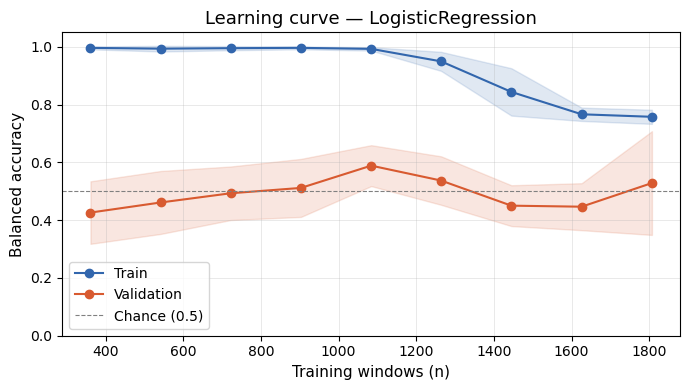

[LogisticRegression] Validation curve verdict: still rising — consider collecting more windows


  SVM

[SVM] Fold 1: balanced_acc=0.514, macro_f1=0.521
[SVM] Fold 2: balanced_acc=0.463, macro_f1=0.459
[SVM] Fold 3: balanced_acc=0.611, macro_f1=0.558
[SVM] Fold 4: balanced_acc=0.859, macro_f1=0.885
[SVM] Fold 5: balanced_acc=0.587, macro_f1=0.584

[SVM] Mean balanced accuracy: 0.607 +/- 0.137
[SVM] Mean macro F1:           0.602 +/- 0.148

[SVM] Mean per-class recall across folds:
  BLRI: 0.480 +/- 0.301
  RI1: 0.330 +/- 0.063
  RI2: 0.905 +/- 0.054

[SVM] Classification report (pooled out-of-fold predictions):
              precision    recall  f1-score   support

        BLRI       0.40      0.51      0.45       694
         RI1       0.45      0.33      0.38       792
         RI2       0.90      0.90      0.90       690

    accuracy                           0.57      2176
   macro avg       0.58      0.58      0.58      2176
weighted avg       0.57      0.57      0.57      2176



,pred_BLRI,pred_RI1,pred_RI2
true_BLRI,356,302,36
true_RI1,493,263,36
true_RI2,47,19,624


c:\Users\thoma\miniconda3\envs\biopipeline-env\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
1 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\thoma\miniconda3\envs\biopipeline-env\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\thoma\miniconda3\envs\biopipeline-env\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\thoma\miniconda3\envs\biopipeline-env\

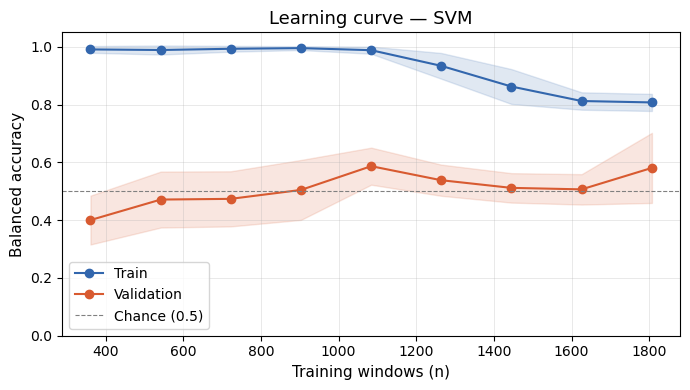

[SVM] Validation curve verdict: still rising — consider collecting more windows


  RandomForest

[RandomForest] Fold 1: balanced_acc=0.396, macro_f1=0.393
[RandomForest] Fold 2: balanced_acc=0.453, macro_f1=0.393
[RandomForest] Fold 3: balanced_acc=0.629, macro_f1=0.488
[RandomForest] Fold 4: balanced_acc=0.670, macro_f1=0.754
[RandomForest] Fold 5: balanced_acc=0.485, macro_f1=0.465

[RandomForest] Mean balanced accuracy: 0.527 +/- 0.105
[RandomForest] Mean macro F1:           0.499 +/- 0.133

[RandomForest] Mean per-class recall across folds:
  BLRI: 0.078 +/- 0.131
  RI1: 0.596 +/- 0.201
  RI2: 0.891 +/- 0.190

[RandomForest] Classification report (pooled out-of-fold predictions):
              precision    recall  f1-score   support

        BLRI       0.09      0.06      0.07       694
         RI1       0.45      0.55      0.49       792
         RI2       0.81      0.86      0.84       690

    accuracy                           0.49      2176
   macro avg       0.45      0.49 

,pred_BLRI,pred_RI1,pred_RI2
true_BLRI,42,539,113
true_RI1,331,437,24
true_RI2,94,1,595


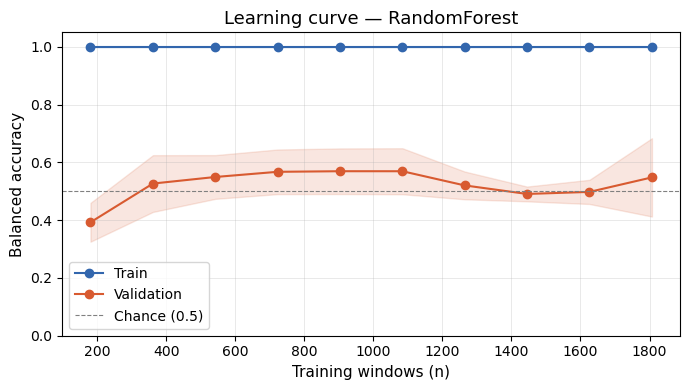

[RandomForest] Validation curve verdict: still rising — consider collecting more windows



In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.metrics import f1_score, recall_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold, learning_curve
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight

# ── CV setup ──────────────────────────────────────────────────────────────────

if groups is not None and pd.Series(groups).nunique() >= 3:
    n_splits_eval = min(5, pd.Series(groups).nunique())
    cv_eval = StratifiedGroupKFold(n_splits=n_splits_eval, shuffle=True, random_state=42)
    cv_eval_mode = f"StratifiedGroupKFold(n_splits={n_splits_eval}, shuffle=True)"
else:
    n_splits_eval = 5
    cv_eval = StratifiedKFold(n_splits=n_splits_eval, shuffle=True, random_state=42)
    cv_eval_mode = "StratifiedKFold(n_splits=5, shuffle=True, random_state=42)"

classes = np.sort(y.unique())
class_weights = compute_class_weight(class_weight="balanced", classes=classes, y=y)
class_weight_map = dict(zip(classes, class_weights))
print(f"CV for evaluation: {cv_eval_mode}")
print("Computed balanced class weights:", class_weight_map)


# ── Split iterator factory ────────────────────────────────────────────────────

def make_split_iterator():
    if groups is not None and pd.Series(groups).nunique() >= 3:
        return StratifiedGroupKFold(
            n_splits=n_splits_eval, shuffle=True, random_state=42
        ).split(X, y, groups=groups)
    return StratifiedKFold(
        n_splits=n_splits_eval, shuffle=True, random_state=42
    ).split(X, y)


# ── Main evaluation function ──────────────────────────────────────────────────

def evaluate_imbalanced_pipeline(base_model, model_name, split_iterator):
    bal_acc_scores, macro_f1_scores = [], []
    per_class_recall = []
    y_true_all, y_pred_all = [], []

    for fold_idx, (train_idx, test_idx) in enumerate(split_iterator, start=1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        fold_sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

        model = clone(base_model)
        model.fit(X_train, y_train, model__sample_weight=fold_sample_weights)

        y_pred = model.predict(X_test)

        present_classes = np.sort(y_test.unique())
        bal_acc = recall_score(
            y_test, y_pred, labels=present_classes, average="macro", zero_division=0
        )
        macro_f1 = f1_score(
            y_test, y_pred, labels=present_classes, average="macro", zero_division=0
        )

        fold_recalls = np.full(len(classes), np.nan)
        present_recalls = recall_score(
            y_test, y_pred, labels=present_classes, average=None, zero_division=0
        )
        for i, cls in enumerate(classes):
            if cls in present_classes:
                fold_recalls[i] = present_recalls[np.where(present_classes == cls)[0][0]]

        bal_acc_scores.append(bal_acc)
        macro_f1_scores.append(macro_f1)
        per_class_recall.append(fold_recalls)

        y_true_all.extend(y_test)
        y_pred_all.extend(y_pred)

        print(f"[{model_name}] Fold {fold_idx}: balanced_acc={bal_acc:.3f}, macro_f1={macro_f1:.3f}")

    per_class_recall = np.array(per_class_recall, dtype=float)

    print(f"\n[{model_name}] Mean balanced accuracy: {np.mean(bal_acc_scores):.3f} +/- {np.std(bal_acc_scores):.3f}")
    print(f"[{model_name}] Mean macro F1:           {np.mean(macro_f1_scores):.3f} +/- {np.std(macro_f1_scores):.3f}")

    print(f"\n[{model_name}] Mean per-class recall across folds:")
    for i, cls in enumerate(classes):
        cls_mean = np.nanmean(per_class_recall[:, i])
        cls_std  = np.nanstd(per_class_recall[:, i])
        print(f"  {cls}: {cls_mean:.3f} +/- {cls_std:.3f}")

    print(f"\n[{model_name}] Classification report (pooled out-of-fold predictions):")
    print(classification_report(y_true_all, y_pred_all, labels=classes, zero_division=0))

    cm = confusion_matrix(y_true_all, y_pred_all, labels=classes)
    cm_df = pd.DataFrame(
        cm,
        index=[f"true_{c}" for c in classes],
        columns=[f"pred_{c}" for c in classes]
    )
    display(cm_df)


# ── Learning curve function ───────────────────────────────────────────────────

def plot_learning_curve(base_model, model_name, train_sizes=np.linspace(0.1, 1.0, 10)):
    """
    Plots training vs. validation balanced accuracy as a function of training set size.
    
    How to read it:
      - Large gap between train and val  →  overfitting (need more data or regularisation)
      - Both curves flat and low         →  underfitting (model too simple)
      - Val curve still rising at 100%   →  you need more windows
      - Val curve flattened              →  adding more data won't help much
    """

    # learning_curve doesn't accept fit_params for sample_weight easily,
    # so we score on balanced_accuracy directly without per-fold sample weights.
    # The shape of the curve is still diagnostic even without them.
    cv_lc = (
        StratifiedGroupKFold(n_splits=n_splits_eval, shuffle=True, random_state=42)
        if groups is not None and pd.Series(groups).nunique() >= 3
        else StratifiedKFold(n_splits=n_splits_eval, shuffle=True, random_state=42)
    )

    lc_kwargs = dict(
        estimator=base_model,
        X=X,
        y=y,
        cv=cv_lc,
        scoring="balanced_accuracy",
        train_sizes=train_sizes,
        n_jobs=-1,
        return_times=False,
    )
    if groups is not None and pd.Series(groups).nunique() >= 3:
        lc_kwargs["groups"] = groups

    train_sizes_abs, train_scores, val_scores = learning_curve(**lc_kwargs)

    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(train_sizes_abs, train_mean, "o-", color="#3266ad", label="Train")
    ax.fill_between(train_sizes_abs, train_mean - train_std, train_mean + train_std, alpha=0.15, color="#3266ad")
    ax.plot(train_sizes_abs, val_mean, "o-", color="#d85a30", label="Validation")
    ax.fill_between(train_sizes_abs, val_mean - val_std, val_mean + val_std, alpha=0.15, color="#d85a30")

    ax.set_title(f"Learning curve — {model_name}", fontsize=13)
    ax.set_xlabel("Training windows (n)", fontsize=11)
    ax.set_ylabel("Balanced accuracy", fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, label="Chance (0.5)")
    ax.legend(fontsize=10)
    ax.grid(True, linewidth=0.4, alpha=0.5)
    plt.tight_layout()
    plt.show()

    # Print a simple data-sufficiency verdict
    val_slope = val_mean[-1] - val_mean[-3]   # change over last 30% of sizes
    if val_slope > 0.02:
        verdict = "still rising — consider collecting more windows"
    elif val_mean[-1] < 0.55:
        verdict = "flat but low — model may need different features, not more data"
    else:
        verdict = "flattened — data volume looks sufficient for this model"
    print(f"[{model_name}] Validation curve verdict: {verdict}\n")


# ── Run everything ────────────────────────────────────────────────────────────

for model, name in [(logreg_clf, "LogisticRegression"),
                    (svm_clf,    "SVM"),
                    (rf_clf,     "RandomForest")]:

    print(f"\n{'='*80}")
    print(f"  {name}")
    print(f"{'='*80}\n")

    evaluate_imbalanced_pipeline(model, name, make_split_iterator())
    print()
    plot_learning_curve(model, name)

In [19]:
# NaN audit + drop columns/rows with excessive missingness
COL_NAN_THRESHOLD = 0.40
ROW_NAN_THRESHOLD = 0.40

nan_by_col = feature_matrix.isna().sum().sort_values(ascending=False)
nan_by_row = feature_matrix.isna().sum(axis=1)

total_nans = int(nan_by_col.sum())
col_nan_frac = feature_matrix.isna().mean(axis=0)
row_nan_frac = feature_matrix.isna().mean(axis=1)

cols_to_drop = col_nan_frac[col_nan_frac > COL_NAN_THRESHOLD].index.tolist()
rows_to_drop = row_nan_frac[row_nan_frac > ROW_NAN_THRESHOLD].index.tolist()

feature_matrix_clean = (
    feature_matrix
    .drop(columns=cols_to_drop)
    .drop(index=rows_to_drop)
    .reset_index(drop=True)
)

print(f"Total NaNs in feature_matrix: {total_nans}")
print(f"Columns with >=1 NaN: {(nan_by_col > 0).sum()} / {feature_matrix.shape[1]}")
print(f"Rows with >=1 NaN: {(nan_by_row > 0).sum()} / {feature_matrix.shape[0]}\n")

print(f"Columns dropped (> {COL_NAN_THRESHOLD:.0%} NaN): {len(cols_to_drop)}")
if cols_to_drop:
    display(col_nan_frac.loc[cols_to_drop].sort_values(ascending=False).to_frame("nan_fraction"))

print(f"Rows dropped (> {ROW_NAN_THRESHOLD:.0%} NaN): {len(rows_to_drop)}")
print(f"Original shape: {feature_matrix.shape}")
print(f"Cleaned shape: {feature_matrix_clean.shape}")

Total NaNs in feature_matrix: 8793
Columns with >=1 NaN: 8 / 45
Rows with >=1 NaN: 2032 / 2176

Columns dropped (> 40% NaN): 7


,nan_fraction
cv_inhale_pause_dur,0.809283
n_bouts_anogenital_sniffing,0.561121
total_dur_anogenital_sniffing,0.561121
n_bouts_body_sniffing,0.476103
total_dur_body_sniffing,0.476103
n_bouts_facial_sniffing,0.410846
total_dur_facial_sniffing,0.410846


Rows dropped (> 40% NaN): 0
Original shape: (2176, 45)
Cleaned shape: (2176, 38)


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from imblearn.ensemble import RUSBoostClassifier

# Use cleaned matrix if available; otherwise fallback to X from prior prep.
X_search = feature_matrix_clean[kept_feature_cols].copy() if "feature_matrix_clean" in globals() else X.copy()
y_search = y.copy()

# Keep groups aligned with X_search rows when possible.
if groups is not None and len(groups) == len(X_search):
    groups_search = groups.copy()
else:
    groups_search = None

search_scoring = "balanced_accuracy"

models_and_grids = {
    "LogisticRegression": (
        Pipeline([
            ("preprocess", preprocess_numeric),
            ("model", LogisticRegression(max_iter=5000, class_weight="balanced", solver="lbfgs")),
        ]),
        {
            "model__C": [0.01, 0.1, 1.0, 10.0, 100.0],
        },
    ),
    "SVM": (
        Pipeline([
            ("preprocess", preprocess_numeric),
            ("model", SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=42)),
        ]),
        {
            "model__C": [0.1, 1.0, 10.0, 100.0],
            "model__gamma": ["scale", 0.01, 0.1, 1.0],
        },
    ),
    "RandomForest": (
        Pipeline([
            ("preprocess", preprocess_impute_only),
            ("model", RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1)),
        ]),
        {
            "model__n_estimators": [200, 400],
            "model__max_depth": [None, 8, 16],
            "model__min_samples_leaf": [1, 3, 5],
            "model__max_features": ["sqrt", 0.5],
        },
    ),
    "RUSBoost": (
        Pipeline([
            ("preprocess", preprocess_impute_only),
            (
                "model",
                RUSBoostClassifier(
                    estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
                    random_state=42,
                    algorithm="SAMME",
                ),
            ),
        ]),
        {
            "model__n_estimators": [50, 100, 200],
            "model__learning_rate": [0.05, 0.1, 0.5, 1.0],
            "model__sampling_strategy": ["auto", "not minority", "all"],
            "model__replacement": [False, True],
            "model__estimator": [
                DecisionTreeClassifier(max_depth=1, random_state=42),
                DecisionTreeClassifier(max_depth=2, random_state=42),
            ],
        },
    ),
}

grid_search_results = {}

for model_name, (pipe, param_grid) in models_and_grids.items():
    gs = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring=search_scoring,
        cv=cv,
        n_jobs=-1,
        refit=True,
        verbose=0,
    )

    if groups_search is not None and hasattr(cv, "split"):
        gs.fit(X_search, y_search, groups=groups_search)
    else:
        gs.fit(X_search, y_search)

    grid_search_results[model_name] = {
        "best_estimator": gs.best_estimator_,
        "best_score": gs.best_score_,
        "best_params": gs.best_params_,
    }

results_df = pd.DataFrame(
    {
        model: {
            "best_balanced_accuracy_cv": vals["best_score"],
            "best_params": vals["best_params"],
        }
        for model, vals in grid_search_results.items()
    }
).T.sort_values("best_balanced_accuracy_cv", ascending=False)

print("Grid search complete (scoring=balanced_accuracy)")
display(results_df)

for model_name, vals in grid_search_results.items():
    print(f"\n{model_name} best CV balanced_accuracy: {vals['best_score']:.4f}")
    print(f"{model_name} best params: {vals['best_params']}")